In [37]:
import numpy as np
import pandas as pd

np.random.seed(0)

n = 10000

data = {
    "Patient_ID": range(1, n+1),
    "Age": np.random.randint(20, 81, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Blood_Pressure": np.random.randint(80, 181, n),
    "Sugar_Level": np.random.randint(70, 201, n),
    "Cholesterol": np.random.randint(150, 301, n),
    "Heart_Rate": np.random.randint(60, 121, n)
}

df = pd.DataFrame(data)

print(df.head())

   Patient_ID  Age  Gender  Blood_Pressure  Sugar_Level  Cholesterol  \
0           1   64  Female             169          115          240   
1           2   67  Female              99          115          225   
2           3   73  Female             178           90          159   
3           4   20  Female             103          132          272   
4           5   23  Female              96          161          300   

   Heart_Rate  
0          89  
1          89  
2          60  
3          83  
4          70  


In [38]:
print(df.info())        # check data types
print(df.isnull().sum()) # check missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      10000 non-null  int64 
 1   Age             10000 non-null  int64 
 2   Gender          10000 non-null  object
 3   Blood_Pressure  10000 non-null  int64 
 4   Sugar_Level     10000 non-null  int64 
 5   Cholesterol     10000 non-null  int64 
 6   Heart_Rate      10000 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 547.0+ KB
None
Patient_ID        0
Age               0
Gender            0
Blood_Pressure    0
Sugar_Level       0
Cholesterol       0
Heart_Rate        0
dtype: int64


In [39]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [40]:
def risk_level(row):
    try:
        if (row["Blood_Pressure"] > 140 or
            row["Sugar_Level"] > 160 or
            row["Cholesterol"] > 240):
            return "High"
        elif (row["Blood_Pressure"] > 120 or
              row["Sugar_Level"] > 140):
            return "Medium"
        else:
            return "Low"
    except:
        return "Unknown"   # handles errors safely

df["Risk"] = df.apply(risk_level, axis=1)

In [41]:
print(df.describe())

        Patient_ID           Age  Blood_Pressure  Sugar_Level   Cholesterol  \
count  10000.00000  10000.000000    10000.000000  10000.00000  10000.000000   
mean    5000.50000     49.989100      130.230900    135.84080    224.300400   
std     2886.89568     17.608515       29.128505     38.09633     43.522079   
min        1.00000     20.000000       80.000000     70.00000    150.000000   
25%     2500.75000     35.000000      105.000000    103.00000    187.000000   
50%     5000.50000     50.000000      130.000000    136.00000    224.000000   
75%     7500.25000     65.000000      155.000000    169.00000    262.000000   
max    10000.00000     80.000000      180.000000    200.00000    300.000000   

         Heart_Rate  
count  10000.000000  
mean      89.770900  
std       17.598051  
min       60.000000  
25%       74.000000  
50%       90.000000  
75%      105.000000  
max      120.000000  


In [42]:
df["Age_Group"] = pd.cut(df["Age"], bins=[20,40,60,80], labels=["Young","Middle","Old"])

In [43]:
df.groupby("Gender")["Blood_Pressure"].mean()

,Blood_Pressure
Gender,
Female,130.122818
Male,130.338250


In [44]:
df["Risk"].value_counts()

,count
Risk,
High,7445
Medium,1288
Low,1267


In [45]:
df.corr(numeric_only=True)

,Patient_ID,Age,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate
Patient_ID,1.000000,0.012094,-0.011582,-0.000623,-0.005624,-0.010143
Age,0.012094,1.000000,0.020739,0.005232,-0.022271,-0.011661
Blood_Pressure,-0.011582,0.020739,1.000000,-0.003113,-0.006819,-0.021408
Sugar_Level,-0.000623,0.005232,-0.003113,1.000000,0.006911,0.001875
Cholesterol,-0.005624,-0.022271,-0.006819,0.006911,1.000000,-0.002131
Heart_Rate,-0.010143,-0.011661,-0.021408,0.001875,-0.002131,1.000000


In [46]:
import matplotlib.pyplot as plt

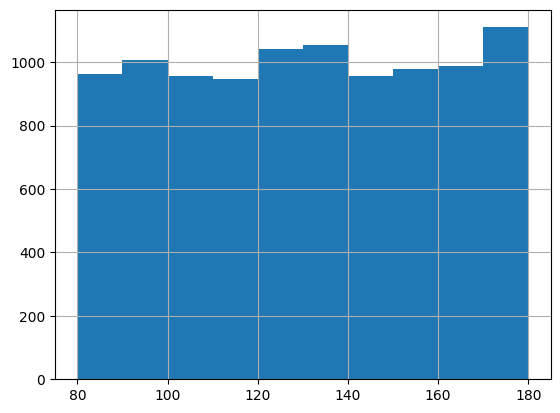

In [47]:
df["Blood_Pressure"].hist()
plt.show()

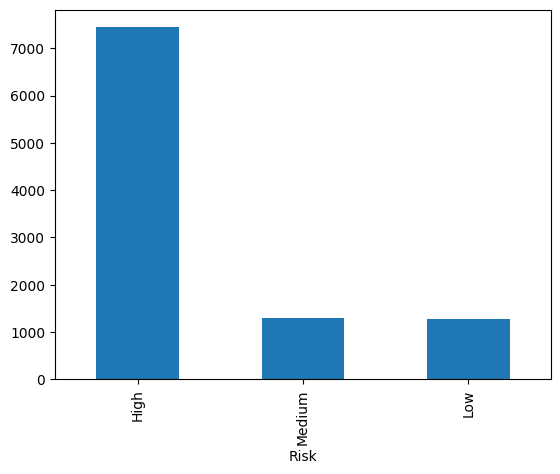

In [48]:
df["Risk"].value_counts().plot(kind='bar')
plt.show()

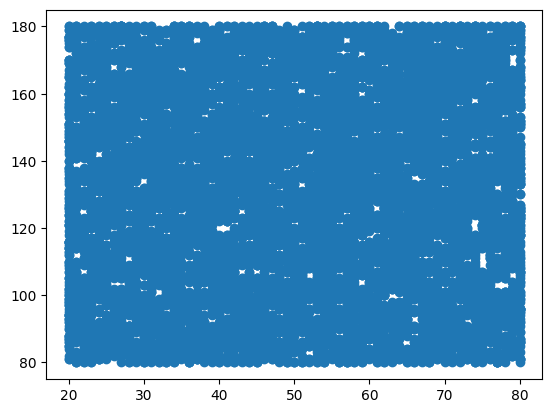

In [49]:
plt.scatter(df["Age"], df["Blood_Pressure"])
plt.show()

In [50]:
import seaborn as sns

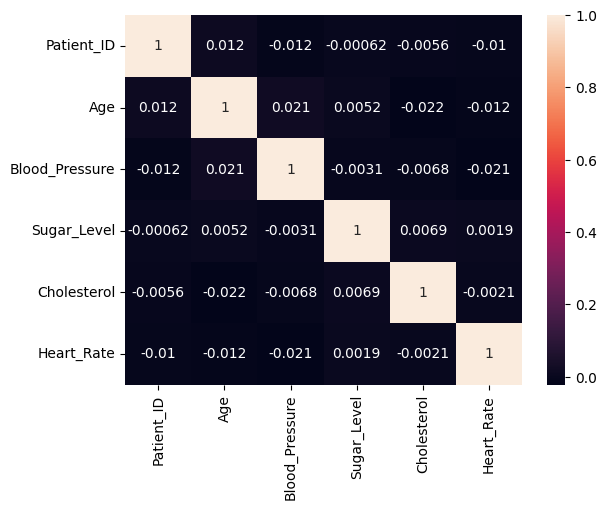

In [51]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()